In [38]:
import os
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ✅ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [39]:
# ----------------------------
# Attributes Dataset
# ----------------------------
class AttributesDataset():
    def __init__(self, annotation_path):
        color_labels, gender_labels, article_labels = [], [], []

        with open(annotation_path) as f:
            reader = csv.DictReader(f)
            for row in reader:
                color_labels.append(row['baseColour'])
                gender_labels.append(row['gender'])
                article_labels.append(row['articleType'])

        self.color_labels = np.unique(color_labels)
        self.gender_labels = np.unique(gender_labels)
        self.article_labels = np.unique(article_labels)

        self.num_colors = len(self.color_labels)
        self.num_genders = len(self.gender_labels)
        self.num_articles = len(self.article_labels)

        self.color_name_to_id = {name: i for i, name in enumerate(self.color_labels)}
        self.gender_name_to_id = {name: i for i, name in enumerate(self.gender_labels)}
        self.article_name_to_id = {name: i for i, name in enumerate(self.article_labels)}

        self.color_id_to_name = {i: name for i, name in enumerate(self.color_labels)}
        self.gender_id_to_name = {i: name for i, name in enumerate(self.gender_labels)}
        self.article_id_to_name = {i: name for i, name in enumerate(self.article_labels)}

# ----------------------------
# Fashion Test Dataset
# ----------------------------
class FashionTestDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, img_path


In [40]:
class MultiOutputModel(nn.Module):
    def __init__(self, n_color_classes, n_gender_classes, n_article_classes):
        super().__init__()
        # Use ResNet18 backbone
        resnet = models.resnet18(pretrained=True)
        self.base_model = nn.Sequential(*list(resnet.children())[:-2])
        last_channel = resnet.fc.in_features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Multi-head outputs
        self.color = nn.Linear(last_channel, n_color_classes)
        self.gender = nn.Linear(last_channel, n_gender_classes)
        self.article = nn.Linear(last_channel, n_article_classes)

    def forward(self, x):
        x = self.base_model(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return {
            'color': self.color(x),
            'gender': self.gender(x),
            'article': self.article(x)
        }

    def get_loss(self, net_output, ground_truth):
        color_loss = F.cross_entropy(net_output['color'], ground_truth['color_labels'])
        gender_loss = F.cross_entropy(net_output['gender'], ground_truth['gender_labels'])
        article_loss = F.cross_entropy(net_output['article'], ground_truth['article_labels'])
        loss = color_loss + gender_loss + article_loss
        return loss, {'color': color_loss, 'gender': gender_loss, 'article': article_loss}


In [41]:
# ----------------------------
# Paths
# ----------------------------
STYLES_CSV = "./dataset/styles.csv"
CHECKPOINT_PATH = "./trained_models/dress_pattern_color_model_20251121_135612/best_model_32.pth"

# ----------------------------
# Load attributes
# ----------------------------
attributes = AttributesDataset(STYLES_CSV)

# ----------------------------
# Load model
# ----------------------------
model = MultiOutputModel(attributes.num_colors, attributes.num_genders, attributes.num_articles).to(device)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint, strict=False)
model.eval()


MultiOutputModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [42]:
# ----------------------------
# Test images
# ----------------------------
TEST_DIR = "../test_images"  # your folder
test_images = [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'))]

print(f"Found {len(test_images)} test images.")


Found 8 test images.


In [43]:
# ----------------------------
# Image transforms
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset & DataLoader
test_dataset = FashionTestDataset(test_images, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


Image: ../test_images\Abstract_Daisy_Print_Blouse_Test.png
Predicted Color: Steel
Predicted Gender: Boys
Predicted Article: Backpacks
------------------------------


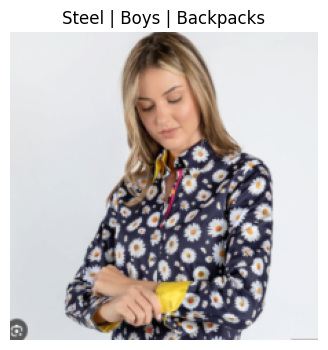

Image: ../test_images\Abstract_Floral_Print_Maxi_Dress_Test.png
Predicted Color: Taupe
Predicted Gender: Boys
Predicted Article: Backpacks
------------------------------


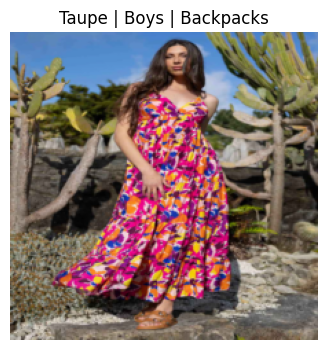

Image: ../test_images\Anchor_Print_Shorts_Test.png
Predicted Color: Skin
Predicted Gender: Boys
Predicted Article: Kurta Sets
------------------------------


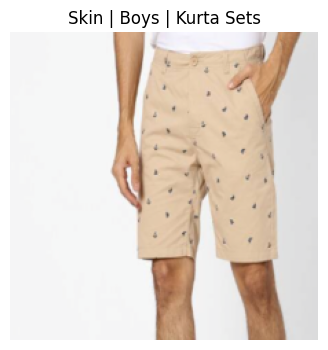

Image: ../test_images\Bleached_Denim_Jacket_Test.png
Predicted Color: Steel
Predicted Gender: Boys
Predicted Article: Kurta Sets
------------------------------


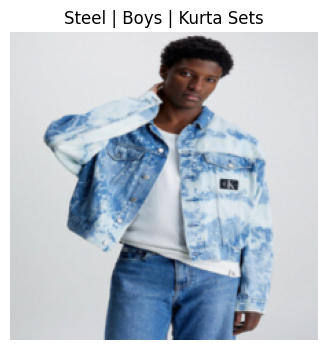

Image: ../test_images\Brooklyn_Nets_Baseball_Tee_Test.png
Predicted Color: Skin
Predicted Gender: Girls
Predicted Article: Laptop Bag
------------------------------


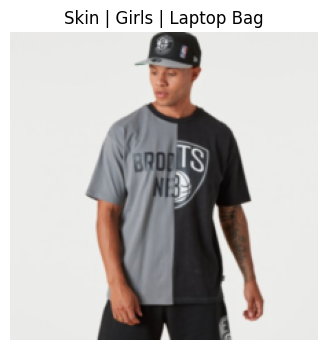

Image: ../test_images\Cheetah_Print_High_Neck_Blouse_Test.png
Predicted Color: Steel
Predicted Gender: Boys
Predicted Article: Laptop Bag
------------------------------


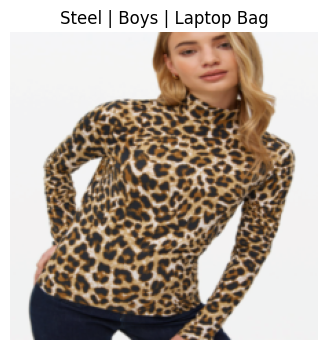

Image: ../test_images\Daisy_Print_Maxi_Skirt_Test.png
Predicted Color: Mushroom Brown
Predicted Gender: Boys
Predicted Article: Baby Dolls
------------------------------


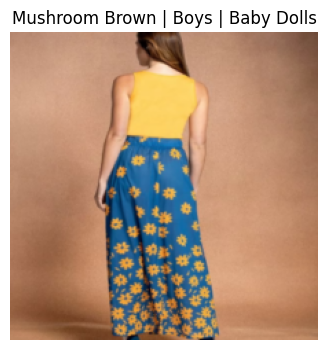

Image: ../test_images\Slim_Fit_Moto_Jeans_Test.png
Predicted Color: Skin
Predicted Gender: Boys
Predicted Article: Heels
------------------------------


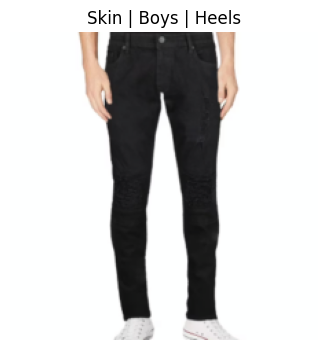

In [44]:
import matplotlib.pyplot as plt

# ----------------------------
# Predict one by one and display
# ----------------------------
with torch.no_grad():
    for img, img_path in test_loader:
        img = img.to(device)
        outputs = model(img)

        color_idx = torch.argmax(outputs['color'], dim=1).item()
        gender_idx = torch.argmax(outputs['gender'], dim=1).item()
        article_idx = torch.argmax(outputs['article'], dim=1).item()

        color_name = attributes.color_id_to_name[color_idx]
        gender_name = attributes.gender_id_to_name[gender_idx]
        article_name = attributes.article_id_to_name[article_idx]

        # Print results
        print(f"Image: {img_path[0]}")
        print(f"Predicted Color: {color_name}")
        print(f"Predicted Gender: {gender_name}")
        print(f"Predicted Article: {article_name}")
        print("-" * 30)

        # ----------------------------
        # Display image
        # ----------------------------
        # Convert tensor to numpy image for plotting
        np_img = img.cpu().squeeze().permute(1, 2, 0).numpy()
        np_img = np.clip(np_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        plt.figure(figsize=(4, 4))
        plt.imshow(np_img)
        plt.axis('off')
        plt.title(f"{color_name} | {gender_name} | {article_name}")
        plt.show()
